# Backpropagation Lab





In [2]:
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split

## 1 Avoiding Overfit: Early Stopping and Loss Regularization

### 1.1 (10%) No overfit avoidance
Train the sklearn [MLP classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier) on the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff).  Use 3 output nodes (1 per class). Expanding the one output variable into 3 is called one-hot encoding or dummy variable encoding. There are lots of ways to implement this including the Pandas get_dummies method. This experiment is set up to run a little longer to better see the effects of overfit.  Be patient as there are lots of hidden nodes and a high max iterations setting.

Use default parameters except for the following:
- hidden_layer_sizes = [64] - One hidden layer with 64 hidden nodes
- activation = 'logistic'
- solver = 'sgd'
- alpha = 0
- batch_size = 1
- learning_rate_init = 0.01
- shuffle = True
- momentum = 0
- n_iter_no_change = 50
- max_iterations = 10000

Use a random 80/20 split of the data.  Run it a few times with different random training/test splits and give average values for
- Number of iterations until convergence
- Training set accuracy
- Test set accuracy
For one run observe the softmax probabilities on the test set using clf.predict_proba

In [2]:
#Iris with no regularization
Iris, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/iris.arff")
Iris_df = pd.DataFrame(Iris)

X = Iris_df.drop(columns=["class"])
y = pd.get_dummies(Iris_df["class"].str.decode('utf-8'))
results = pd.DataFrame()

for n in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=n)
    model = MLPClassifier(hidden_layer_sizes=[64], activation='logistic', solver='sgd', alpha=0, batch_size=1, 
                        learning_rate_init=0.01, shuffle=True, momentum=0, n_iter_no_change=50,max_iter=10000, random_state=n)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], "test_acc": [model.score(X_test,y_test)]})
    results = pd.concat([results, new_row], ignore_index=True)

display(results)
print(f"Avg iterations until convergence: {np.average(results["num_iter"])}")
print(f"Avg training acc: {np.average(results["train_acc"]):.4f}")
print(f"Avg test acc: {np.average(results["test_acc"]):.4f}")
print(f"Example softmax probabilities: {model.predict_proba(X_test)}")

,num_iter,train_acc,test_acc
0,263,0.950000,1.000000
1,272,0.933333,0.966667
2,351,0.950000,0.900000
3,376,0.975000,0.966667
4,314,0.958333,0.933333
5,339,0.991667,0.900000
6,231,0.983333,0.966667
7,430,0.983333,0.900000
8,297,0.975000,0.966667
9,236,0.975000,1.000000


Avg iterations until convergence: 310.9
Avg training acc: 0.9675
Avg test acc: 0.9500
Example softmax probabilities: [[2.70567437e-06 2.34082553e-02 9.93894377e-01]
 [1.95422921e-04 8.49192652e-01 5.94875509e-02]
 [7.02614868e-06 5.78115240e-02 9.71499925e-01]
 [1.18769790e-05 1.18063330e-01 9.24371010e-01]
 [1.28966474e-03 9.75568013e-01 2.27970502e-03]
 [9.98128283e-01 1.38901623e-02 2.17698519e-10]
 [9.97751325e-01 1.20744899e-02 3.05463534e-10]
 [9.97517616e-01 1.55871344e-02 3.20807578e-10]
 [2.08851439e-03 9.94018801e-01 6.64450954e-04]
 [9.98128283e-01 1.38901623e-02 2.17698519e-10]
 [9.96868408e-01 2.32455986e-02 3.74051726e-10]
 [3.37026610e-04 9.46224308e-01 1.84463684e-02]
 [2.79657274e-02 9.93378336e-01 1.79791515e-05]
 [4.79383853e-04 9.42673391e-01 1.23664769e-02]
 [9.98691614e-01 8.73251737e-03 1.57289162e-10]
 [3.82304497e-03 9.93912632e-01 2.89536710e-04]
 [9.98507664e-01 9.10360568e-03 1.88131503e-10]
 [2.25326867e-04 8.76530451e-01 4.56784662e-02]
 [4.17908295e-06 2.

#### Discussion
In the markdown cell below, write about your experience training the MLP classifier. Things to cover in your discussion: How long did it take? What was your accuracy on the training set? What was your accuracy on the testing set? Do you see any evidence of overfitting? If so, what could be done to reduce the effects of overfitting?

**The total time to create and train 10 different models took about 17 seconds which means it teach each roughly 1.7 seconds to train.  According to the calculations of the averages of the runs, each run converged at around 311 iterations and achieved a final train accuracy of 0.9675 and final test accuracy of 0.9500.  Overall it appears that the model did not overfit too much as the average train accuracy is only slightly above the average test accuracy, although I can see that in a few individual runs that there is a much higher train accuracy than test accuracy, indicating likely instances of overfitting.  In cases such as these, overfitting could be further avoided by decreasing the max_iter hyperparameter.**

### 1.2 (10%) Early Stopping (Validation Set)

- Do the same as above but this time with early stopping
- Use a validation set taken from the training set for your stopping criteria. Using 10-15% of the training set for a validation set is common. You do this simply by setting the MLPClassifier early_stopping, validation_fraction, and n_iter_no_change parameters.
- Run it a few times with different training/test splits and give average values for
    - Number of iterations until convergence
    - Training set accuracy
    - Test set accuracy
    - Best validation score (MLPClassifer attribute best_validation_score_)
- For one run create a graph with validation set accuracy (*y*-axis) vs epochs (*x*-axis). Hint: MLPClassifer attribute validation_scores_

Note: Due to the simplicity of and lack of noise in the iris data set you will not see the accuracy improvements that early stopping or loss regularization can give for more complex noisy datasets.  In particular, early stopping will have lower than expected results because with a very small VS taken from a very small training set there is less data to train on and more variance with the VS score.  Thus, you will probably get lower accuracies for VS than normal training for this less typical case.  But at least you will get practice on using early stopping and loss regularization for future data sets.

,num_iter,train_acc,test_acc,best_val_score
0,107,0.933333,0.900000,0.916667
1,119,0.950000,0.966667,1.000000
2,113,0.916667,0.933333,1.000000
3,134,0.991667,0.933333,1.000000
4,115,0.925000,0.866667,1.000000
5,131,0.925000,0.900000,0.916667
6,100,0.933333,0.766667,0.916667
7,125,0.950000,0.900000,1.000000
8,110,0.916667,1.000000,1.000000
9,106,0.858333,0.666667,1.000000


Avg iterations until convergence: 116.0
Avg training acc: 0.9300
Avg test acc: 0.8833
Avg best_val_score: 0.9750


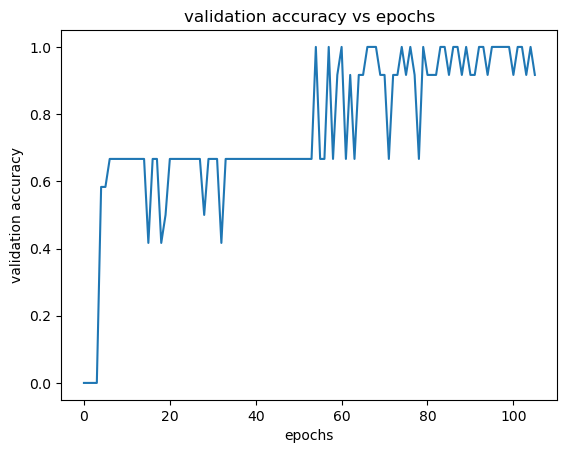

In [3]:
#Iris with early stopping and validation scores graph
Iris, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/iris.arff")
Iris_df = pd.DataFrame(Iris)

X = Iris_df.drop(columns=["class"])
y = pd.get_dummies(Iris_df["class"].str.decode('utf-8'))
results = pd.DataFrame()

for n in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=n+1)
    model = MLPClassifier(hidden_layer_sizes=[64], activation='logistic', solver='sgd', alpha=0, batch_size=1, 
                        learning_rate_init=0.01, shuffle=True, momentum=0, n_iter_no_change=50, max_iter=10000, early_stopping=True, validation_fraction=0.1, random_state=n)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], 
                            "test_acc": [model.score(X_test,y_test)], "best_val_score": [model.best_validation_score_]})
    results = pd.concat([results, new_row], ignore_index=True)

display(results)
print(f"Avg iterations until convergence: {np.average(results["num_iter"])}")
print(f"Avg training acc: {np.average(results["train_acc"]):.4f}")
print(f"Avg test acc: {np.average(results["test_acc"]):.4f}")
print(f"Avg best_val_score: {np.average(results["best_val_score"]):.4f}")

# Create plot of validation scores for final run
plt.plot(model.validation_scores_)
plt.xlabel("epochs")
plt.ylabel("validation accuracy")
plt.title("validation accuracy vs epochs")
plt.show()

#### Discussion
Report on the average number of iterations until convergence. What is the effect of the use of the validation set and early stopping on training set accuracy and testing set accuracy? What do you attribute the performance change to? What do you see in the validation scores graph?

**With the early stopping methods included in the training, the model converged at around 116 iterations with an average train accuracy of 0.9300, an average test accuracy of 0.8833, and an average best_val_score of 0.9750.  These train and test accuracies are worse than before and could be attributed to the note above about the rare simplicity and lack of noise in the Iris dataset that are not usually seen in other datasets.  In the graph of the validation scores, we see jumps between differing levels of validation accuracy for each epoch with it reaching occasional near perfect accuracy around 50 epochs and achieving higher scores more consistently as epochs increase.**

### 1.3 (10%) Loss Regularization

- Do the same as in 1.1 but his time with loss regularization (Do not do early stopping)
- Run it with different L2 regularization parameter values (alpha).  The default for alpha is .0001.  Try other values such as .1, .01, .001, .00001, etc. Make a table with each row including:
    - The regularization parameter value
    - Number of iterations until convergence
    - Training set accuracy
    - Test set accuracy
    - Best loss value (MLPClassifer attribute best_loss_)
- Which regularization value gave you the best results?
- For your best regularization value do one run and create a graph with loss (*y*-axis) vs epochs (*x*-axis) for the training set (Hint: MLPClassifer attribute loss_curve_)

,alpha,num_iter,train_acc,test_acc,best_loss_value
0,1.000000e-01,167,0.333333,0.333333,1.630433
1,1.000000e-02,227,0.958333,0.966667,0.806646
2,1.000000e-03,331,0.975000,0.966667,0.245181
3,1.000000e-04,331,0.975000,0.966667,0.138857
4,1.000000e-05,331,0.975000,0.966667,0.126285
5,1.000000e-06,331,0.975000,0.966667,0.125002
6,1.000000e-07,331,0.975000,0.966667,0.124874
7,1.000000e-08,331,0.975000,0.966667,0.124861
8,1.000000e-09,331,0.975000,0.966667,0.124859


Best regularization value: 1e-09


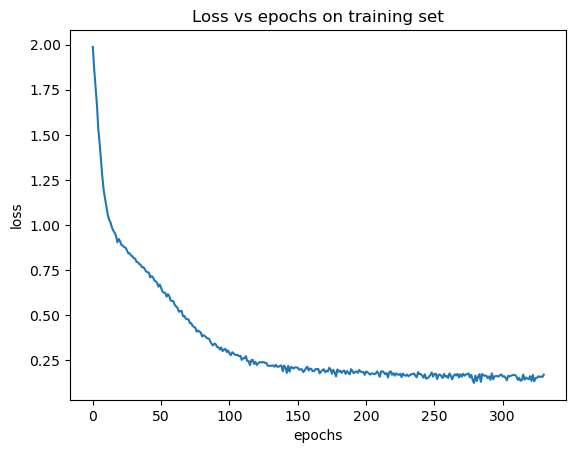

In [59]:
#Iris with Loss Regularization 
Iris, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/iris.arff")
Iris_df = pd.DataFrame(Iris)

X = Iris_df.drop(columns=["class"])
y = pd.get_dummies(Iris_df["class"].str.decode('utf-8'))
results = pd.DataFrame()

for a in [10**-n for n in range(1,10)]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = MLPClassifier(hidden_layer_sizes=[64], activation='logistic', solver='sgd', alpha=a, batch_size=1, 
                        learning_rate_init=0.01, shuffle=True, momentum=0, n_iter_no_change=50, max_iter=10000, random_state=42)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"alpha": [a], "num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], 
                            "test_acc": [model.score(X_test,y_test)], "best_loss_value": [model.best_loss_]})
    results = pd.concat([results, new_row], ignore_index=True)

display(results)
best_alpha = results.loc[results["best_loss_value"].idxmin()]["alpha"]
print(f"Best regularization value: {best_alpha}")
model = MLPClassifier(hidden_layer_sizes=[64], activation='logistic', solver='sgd', alpha=best_alpha, batch_size=1, 
                        learning_rate_init=0.01, shuffle=True, momentum=0, n_iter_no_change=50, max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# Create graph of loss vs epochs for training set
plt.plot(model.loss_curve_)
plt.title("Loss vs epochs on training set")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

#### Discussion
Write about which regularization method gave you the best results and why you think that happened. Also compare: no regularization, early stopping, and L2 loss regularization.

**I found that the best regularization value was alpha=1e-09 because it produced better than or equal to all the other test accuracies while having the lowest loss value.  It could also be argued that some of the other larger alpha values are better since they produce the same test accuracy and only minorly change the loss values. For each alpha, the weights are able to be regularized so that it does not become overfit to the training data. It can easily be seen that with alpha=0.1, the model becomes severely underfit.  Overall, between no regularization, early stopping, and L2 loss regularization, at least for the example of the fairly simple Iris dataset, I would say that L2 loss regularization performs the best as it consistently achieves high test accuracy of around 96.66% while in both cases of using no regularation or using early stopping, the accuracies fluctuated and were more inconsistent, even if occassionally achieving higher test accuracy.**

## 2 Hyperparameters 
In this section we use the [Vowel Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff) to consider the hyperparameters of learning rate, number of hidden nodes, and momentum. 

### 2.1 (10%) Vowel Dataset Questions
- Give the baseline accuracies for the Iris and Vowel datasets. Baseline accuracy is what you would get if the model just outputs the majority class of the data set (i.e. the output value which occurs most often). These two data sets are not great examples for this as they have an equal amount of each class, which is not typical.
- Discuss why the vowel data set will probably have lower accuracy than Iris.
- Consider which of the vowel dataset's input features you should not use in training and discuss why.

In [5]:
# Get baseline accuracy for Iris data
Iris, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/iris.arff")
Iris_df = pd.DataFrame(Iris)
display(Iris_df["class"].value_counts())
print(f"Baseline accuracy for Iris data: {Iris_df["class"].value_counts().max()/Iris_df["class"].count()}")

# Get baseline accuracy for Vowel data
Vowel, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/Vowel.arff")
Vowel_df = pd.DataFrame(Vowel)
display(Vowel_df["Class"].value_counts())
print(f"Baseline accuracy for Vowel data: {Vowel_df["Class"].value_counts().max()/Vowel_df["Class"].count()}")
display(Vowel_df)

class
b'Iris-setosa'        50
b'Iris-versicolor'    50
b'Iris-virginica'     50
Name: count, dtype: int64

Baseline accuracy for Iris data: 0.3333333333333333


Class
b'hid'    90
b'hId'    90
b'hEd'    90
b'hAd'    90
b'hYd'    90
b'had'    90
b'hOd'    90
b'hod'    90
b'hUd'    90
b'hud'    90
b'hed'    90
Name: count, dtype: int64

Baseline accuracy for Vowel data: 0.09090909090909091


,Train or Test,Speaker Number,Sex,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Class
0,b'Train',b'Andrew',b'Male',-3.639,0.418,-0.670,1.779,-0.168,1.627,-0.388,0.529,-0.874,-0.814,b'hid'
1,b'Train',b'Andrew',b'Male',-3.327,0.496,-0.694,1.365,-0.265,1.933,-0.363,0.510,-0.621,-0.488,b'hId'
2,b'Train',b'Andrew',b'Male',-2.120,0.894,-1.576,0.147,-0.707,1.559,-0.579,0.676,-0.809,-0.049,b'hEd'
3,b'Train',b'Andrew',b'Male',-2.287,1.809,-1.498,1.012,-1.053,1.060,-0.567,0.235,-0.091,-0.795,b'hAd'
4,b'Train',b'Andrew',b'Male',-2.598,1.938,-0.846,1.062,-1.633,0.764,0.394,-0.150,0.277,-0.396,b'hYd'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,b'Test',b'Wendy',b'Female',-3.239,3.083,-1.427,-0.202,-0.282,1.421,0.576,0.068,-0.914,0.147,b'hOd'
986,b'Test',b'Wendy',b'Female',-3.753,3.605,-0.899,-0.747,-0.401,1.765,0.620,0.754,-0.835,-0.301,b'hod'
987,b'Test',b'Wendy',b'Female',-3.980,2.459,0.068,0.023,0.237,1.029,-0.189,0.521,-0.773,-0.500,b'hUd'
988,b'Test',b'Wendy',b'Female',-4.264,2.925,0.065,0.794,0.323,0.515,-1.282,-0.140,-0.863,-0.390,b'hud'


**The baseline accuracy for the Iris data is 0.3333 and the baseline accuracy for the Vowel data is 0.0909.  This difference in baseline accuracy makes sense because the Vowel data has 11 classes while the Iris data only has 3 classes, making it much harder to classify.  When it comes to training a model on the Vowel dataset, I would split the data according to the train and test tags (to avoid data leakage) and then remove the Speaker Number and Sex.  I would remove the Speaker Number input feature because each speaker was assigned to be exclusively in the train or the test set, making the train and test sets disjoint. It could go either way on whether or not to keep the Sex input feature depending on the goal and context of the model because it allows the model to use the information on whether a male or a female is talking, but if the model should only be predicting based off of purely acoustics, it should be removed.**

### 2.2 (10%) Learning Rate
Load the [Vowel Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff). Drop any features which you explained above as being inappropriate for training.

Hints: Consider the Pandas drop method for dropping columns. When you want to transform features in your data set there are lots of approaches. You could edit the arff file directly, or make the transforms in your code.  The Pandas replace method is nice for that. For example, if you wanted to change the vowel data set gender feature in a Pandas dataframe to 0/1 you could do the following:

vowel_df['Sex'] = vowel_df['Sex'].str.decode('utf-8')   //Changes the byte code data into a normal string, b'Male' becomes "Male"\
vowel_df = vowel_df.replace('Male', 0)\
vowel_df = vowel_df.replace('Female', 1)

- Use one layer of hidden nodes with the number of hidden nodes being twice the number of inputs.
- Use a random 75/25 split of the data for the training/test set.
- Do not use early stopping.
- Try at least 5 different learning rates (LR) from very small (e.g. .001) to pretty big (e.g. 10). Each LR will require a different number of epochs to learn. LR effects both accuracy and time required for learning.
- Create a table which includes a row for each LR.  Your table columns should be LR, # epochs to learn the model, final training set accuracy and final test set accuracy.  As learning rates get smaller, it usually takes more epochs to learn. If your model is stopping learning too soon (converging) by hitting max_iterations (in this case and in experiments below), then you need to increase your max_iterations parameter in order to give your model more learning time.  To keep things faster, you don't need to increase max_iter past 1000 if you don't want to, but point out when more iterations may have given improvement.

In real testing one averages the results of multiple trials per LR (and other parameters) with different intitial conditions (training/test split, initial weights, etc.). That gives more accurate results but is not required for this lab.

In [2]:
# Train with different learning rates
Vowel, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/Vowel.arff")
Vowel_df = pd.DataFrame(Vowel)
X = Vowel_df.drop(columns=["Train or Test", "Speaker Number", "Sex", "Class"])
y = pd.get_dummies(Vowel_df["Class"].str.decode('utf-8'))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
results = pd.DataFrame()

for lr in [10**n for n in range(-3, 2)]:
    model = MLPClassifier(hidden_layer_sizes=[2*len(X_train)], learning_rate_init=lr, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"learning_rate": [lr], "num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], 
                            "test_acc": [model.score(X_test,y_test)]})
    results = pd.concat([results, new_row], ignore_index=True)

display(results)

,learning_rate,num_iter,train_acc,test_acc
0,0.001,942,1.000000,0.875000
1,0.010,192,0.993261,0.883065
2,0.100,205,1.000000,0.850806
3,1.000,119,0.128032,0.129032
4,10.000,175,0.048518,0.048387


#### Discussion
Discuss your table and the effect of different learning rates on both training time and accuracy

**As seen in the table above, the learning rate that achieved the highest test accuracy is 0.01 with a test accuracy of 0.883, alhtough learning rates of 0.001 and 0.1 achieved only slightly lower test accuracies.  We see as well that using a learning rate of 0.001 resulted in a much higher number of iterations to train, making training time much longer.  From the table we can see that there is a balance on the learning rate not being too high but also not being too low.**

### 2.3 (10%) Number of Hidden Nodes

Using the best LR you discovered, experiment with different numbers of hidden nodes.

- Start with 1 hidden node, then 2, and then double them for each test until you get no more improvement in accuracy. 
- Create a table just like above, except with # of hidden nodes rather than LR.

In general, whenever you are testing a parameter such as # of hidden nodes, keep testing values until no more improvement is found. For example, if 20 hidden nodes did better than 10, you would not stop at 20, but would try 40, etc., until you no longer got improvement.

In [3]:
# Train with different numbers of hidden nodes
Vowel, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/Vowel.arff")
Vowel_df = pd.DataFrame(Vowel)
X = Vowel_df.drop(columns=["Train or Test", "Speaker Number", "Sex", "Class"])
y = pd.get_dummies(Vowel_df["Class"].str.decode('utf-8'))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

results = pd.DataFrame()
best_accuracy = 0
hidden_nodes = 1
while True:
    if best_accuracy != 0:
        hidden_nodes *= 2
    model = MLPClassifier(hidden_layer_sizes=[hidden_nodes], learning_rate_init=0.01, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"num_hidden_nodes": [hidden_nodes], "num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], 
                            "test_acc": [model.score(X_test,y_test)]})
    results = pd.concat([results, new_row], ignore_index=True)
    curr_accuracy = model.score(X_test,y_test)
    if curr_accuracy > best_accuracy or best_accuracy < 0.5:
        best_accuracy = curr_accuracy
        continue
    else:
        break

display(results)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,num_hidden_nodes,num_iter,train_acc,test_acc
0,1,528,0.053908,0.028226
1,2,789,0.181941,0.145161
2,4,762,0.169811,0.125000
3,8,583,0.525606,0.399194
4,16,1000,0.814016,0.657258
5,32,809,0.954178,0.737903
6,64,709,1.000000,0.826613
7,128,592,1.000000,0.854839
8,256,483,1.000000,0.846774


#### Discussion
Discuss your table and the effect of different numbers of hidden nodes on both training time and accuracy

**As seen in the table above, as number of nodes increased, the number of iterations to train the model didn't seem to consistently go up or down, with the longest training occuring with num_hidden_nodes=16.  After initially running my code, I was stopped at num_hidden_nodes=4 since it got a worse test accuracy, but as it could reasonably be assumed that a better testing accuracy than 0.14 could be achieved, I added an extra statement making sure the model kept doubling num_hidden_nodes until the test accuracy was at least 0.5.  This resulted in going all the way up to 128 hidden nodes before improvement in performance stopped.  With 128 hidden nodes, the model achieved a test accuracy of 0.8548.**

### 2.4 (10%) Momentum

Try at least 5 different momentum terms between 0 and just less than 1 using the best number of hidden nodes and LR from your earlier experiments.

- Create a table just like above, except with momentum values rather than LR or number of hidden nodes.

In [ ]:
# Train with different momentum values
Vowel, meta = arff.loadarff("/Users/prestonhancock/Desktop/cs270/Backpropagation_Lab/Vowel.arff")
Vowel_df = pd.DataFrame(Vowel)
X = Vowel_df.drop(columns=["Train or Test", "Speaker Number", "Sex", "Class"])
y = pd.get_dummies(Vowel_df["Class"].str.decode('utf-8'))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

results = pd.DataFrame()
# Test values between 0 and 1
for momentum in np.arange(0, 1, 0.2):
    model = MLPClassifier(hidden_layer_sizes=[128], learning_rate_init=0.01, solver="sgd", momentum = momentum, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"momentum": [momentum], "num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], 
                            "test_acc": [model.score(X_test,y_test)]})
    results = pd.concat([results, new_row], ignore_index=True)

# Test more values between 0.9 and 1
for momentum in np.arange(0.9, 1, 0.02):
    model = MLPClassifier(hidden_layer_sizes=[128], learning_rate_init=0.01, solver="sgd", momentum = momentum, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"momentum": [momentum], "num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], 
                            "test_acc": [model.score(X_test,y_test)]})
    results = pd.concat([results, new_row], ignore_index=True)

# Test more values between 0.98 and 1
for momentum in np.arange(0.98, 1, 0.005):
    model = MLPClassifier(hidden_layer_sizes=[128], learning_rate_init=0.01, solver="sgd", momentum = momentum, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    new_row = pd.DataFrame({"momentum": [momentum], "num_iter": [model.n_iter_], "train_acc": [model.score(X_train, y_train)], 
                            "test_acc": [model.score(X_test,y_test)]})
    results = pd.concat([results, new_row], ignore_index=True)

display(results)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

,momentum,num_iter,train_acc,test_acc
0,0.000,1000,0.303235,0.221774
1,0.200,1000,0.335580,0.270161
2,0.400,1000,0.436658,0.318548
3,0.600,1000,0.530997,0.387097
4,0.800,1000,0.704852,0.612903
5,0.900,1000,0.907008,0.762097
6,0.920,1000,0.932615,0.790323
7,0.940,1000,0.964960,0.806452
8,0.960,1000,0.993261,0.822581
9,0.980,1000,0.998652,0.838710


#### Discussion
Discuss your table and the effect of momentum on both training time and accuracy

**As seen in the table above, increasing momentum improved training accuracy until momentum=0.98, afterwhich it started to hinder test accuracy.  It was at this point that increasing the momentum also decreased training time with the number of iterations falling below the set threshold of max_iter = 1000. We see that high momentum values can be very beneficial, although with values too close to 1, the model can get worse. Training the models for more iterations and not capping it at max_iter = 1000 could have given us slightly different results.**

### 2.5 (10%) Automatic Hyperparameter Discovery
Using the vowel dataset, automatically adjust the LR, # of hidden nodes, and momentum using [grid and random search](https://scikit-learn.org/stable/modules/grid_search.html) 
- For grid search include the most promising hyperparameter values you used in your experiments above.  You may add others also.
- Be patient as the grid search can take a while since it has to train all combinations of models. Don't use too many parameter options or it will be too slow.
- Report your best hyperparameters and accuracy.  Unfortunately, you will not always get as high a score as you might expect.  This is in part due to the simplicity of the dataset.  It also teaches that in gerneral you should not blindly assume that a tool will get you the results you expect, and that you may need to consider multiple approaches.

In [17]:
#Grid search for hyperparameters.
#Here is one variation of code you could use for your grid search. You can try your own variation if you prefer.

from sklearn.model_selection import GridSearchCV
clf = MLPClassifier(activation='logistic', solver='sgd', alpha=0, early_stopping=True, n_iter_no_change=10, batch_size=1, random_state=42)
parameters = {'learning_rate_init':( .001, .01, 0.1),
              'hidden_layer_sizes': ([64], [128], [256]),
              'momentum':(0.9, 0.98, 0.99),
}
grid = GridSearchCV(clf, parameters)
grid.fit(X, y)    #This takes a while to run
print(grid.best_params_)
print(grid.best_score_)

{'hidden_layer_sizes': [64], 'learning_rate_init': 0.001, 'momentum': 0.99}
0.40808080808080804


In [21]:
#Randomized search for hyperparameters
#Here is one variation of code you could use for your randomized search.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
clf = MLPClassifier(activation='logistic', solver='sgd', alpha=0, early_stopping=True, n_iter_no_change=10, batch_size=1, random_state=42)
distributions = dict(learning_rate_init=uniform(loc=.001, scale=0.099), #loc is the min val, and loc + scale is the max val
                    hidden_layer_sizes = ([64],[128],[256]), #since there is no distribution it samples these values uniformly
                    momentum=uniform(loc=0.95, scale =.04))
search = RandomizedSearchCV(clf, distributions, n_iter=10, random_state=42)
search.fit(X, y)
print(search.best_params_)
print(search.best_score_)

{'hidden_layer_sizes': [256], 'learning_rate_init': 0.0030378649352844423, 'momentum': 0.9887963940864797}
0.3717171717171717


#### Discussion
Write about and compare grid and randomized parameter search. How much time do they take? Which is more efficient or accurate? When should you use each?

**Both the grid search and the randomized parameter search are helpful ways to find optimal hyperparameters for a model but they can both be more helpful in different ways. In this experiment, the grid search took nearly four minutes while the random search took about one minute, with the grid search achieving slightly higher accuracy than the random search.  The grid search takes a lot longer to run but can be nice to use as it lets you put in clear and clean hyperparameter values for it to check while also making sure it is as thorough as you want it to be, giving deterministic results. The randomized search is much faster and can be nice when you have a general idea on the range of a hyperparameter but might not know more information than that. Ultimately, a grid search can be more thorough while the random search can be faster and convenient when the most optimal solution is not required or you have less compute power.**

## 3 Regression with MLPs

### 3.1 (10%) - Learn a regression data set of your choice

Train MLP on any real world data set that requires regression (i.e. has a real valued ouput) and discuss your effort and results.  While the [Irvine ML Repository](https://archive.ics.uci.edu) is a great resource, also onsider [Kaggle](https://www.kaggle.com) and [OpenML](https://openml.org) as other great places to find datasets.
- Use [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor) rather than MLPclassifier.  It has almost the exact same setup as MLPClassier except it uses the linear activation function for the output nodes and SSE as the loss function.  MLPClassier uses softmax activation for the output nodes and cross-entropy for the loss function.
- Use any reasonable hyperparameters that you want.  
- You will probably need to normalize input features.
- It is not typically necessary to normalize the output.
- Split into train and test and report the training and test set MAEs (Mean Absolute Error). For regression problems where we don't normalize the output, MAE is an intuitive measure as it shows exactly how much our output is off on average.

In [39]:
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Load and Learn a real world regression data set
Munich_housing, meta = arff.loadarff("Munich_housing.arff")
Munich_housing_df = pd.DataFrame(Munich_housing)
X = pd.get_dummies(Munich_housing_df.drop(columns=["rent", "rentsqm"]))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = Munich_housing_df["rent"]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=42)

model = MLPRegressor(hidden_layer_sizes=[128,], alpha = 0.01, random_state=42, max_iter = 200)
model.fit(X_train, y_train)

print(f"Training MAE: {mean_absolute_error(model.predict(X_train), y_train)}")
print(f"Testing MAE: {mean_absolute_error(model.predict(X_test), y_test)}")
print(f"Example: input {X_train[0]} → prediction {model.predict(X_train[0].reshape(1,-1))[0]}")

Training MAE: 104.27072752122965
Testing MAE: 104.00278344579428
Example: input [-0.18445971 -1.71736683 -0.89520516  0.84731855 -0.80396985 -0.16113777
  0.25703522 -0.25703522  0.21069345 -0.21069345  2.93278811 -2.93278811] → prediction 307.608046817993


#### Discussion
Report on your choice of data set and your results. How does the MLPRegressor differ from the MLPClassifier? What are their respective uses? What lessons from above did you use?

**For my dataset I chose to use data about rent (in Euros) in Munich.  Creating a MLPRegressor on the data resulted in a training MAE of 104.27 and a testing MAE of 104.00, showing that not too much overfitting is happening but maybe just a little.  The MLPRegressor is different in the fact that by having a linear activation at the end of the model, a single value is returned rather than a list of probabilities cooresponding to the different classes.  This makes the MLPRegressor good for regression problems while the MLPClassifier is good for classification problems, as indicated by their respective names.  While setting up and running my model on the data, I made sure to regularize the data as I saw that was beneficial from previous experiments. I used a high number of hidden layers as I saw that it performed better similar to my experiments earlier.**

### 3.2 (10%) - Other MLP Hyperparameters 
With the same data set, you may (not required) experiment with some of the hyperparameters you already did above (LR, hidden nodes, momentum, validation set parameters, regularization).  But for sure experiment with and discuss the results of the first two hyperparameters below (activation functions and multiple hidden layers).  We encourage you to experiment briefly with the others but they are not required. 

- different hidden layer activation functions (tanh, relu in addition to logistic) - Note that Sklearn does not currently let you choose the output layer activation function.  It is automatically softmax for classification and linear for regression.
- more than one hidden layer
- solver - try adam and lbfgs in addition to sgd
- batch size
- learning rate adaptation - this is the schedule parameter which lets LR adapt during learning

In [32]:
import warnings
warnings.filterwarnings('ignore')

Munich_housing, meta = arff.loadarff("Munich_housing.arff")
Munich_housing_df = pd.DataFrame(Munich_housing)
X = pd.get_dummies(Munich_housing_df.drop(columns=["rent", "rentsqm"]))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = Munich_housing_df["rent"]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=42)

results = pd.DataFrame()
for activation in ["relu", "logistic", "tanh"]:
    for hidden_layers in [(128,), (128,128,), (128,128,128)]:
        for solver in ["adam", "lbfgs", "sgd"]:
            if solver == "sgd" and activation == "relu":
                continue
            model = MLPRegressor(hidden_layer_sizes=hidden_layers, learning_rate_init=0.0001, solver = solver, alpha = 0.01, activation = activation, random_state=42)
            model.fit(X_train, y_train)
            new_row = pd.DataFrame({"activation": [activation], "solver": [solver], "hidden_layers": [hidden_layers], "train_MAE": [mean_absolute_error(model.predict(X_train), y_train)], 
                                "test_MAE": [mean_absolute_error(model.predict(X_test), y_test)]})
            results = pd.concat([results, new_row], ignore_index=True)

display(results)

,activation,solver,hidden_layers,train_MAE,test_MAE
0,relu,adam,"(128,)",426.912551,438.134948
1,relu,lbfgs,"(128,)",91.432718,108.326794
2,relu,adam,"(128, 128)",106.676360,106.614851
3,relu,lbfgs,"(128, 128)",89.717992,105.756422
4,relu,adam,"(128, 128, 128)",102.289513,101.363838
5,relu,lbfgs,"(128, 128, 128)",84.520374,108.961462
6,logistic,adam,"(128,)",437.516334,448.414849
7,logistic,lbfgs,"(128,)",78.791534,109.475744
8,logistic,sgd,"(128,)",98.187885,99.089760
9,logistic,adam,"(128, 128)",429.839617,440.594869


#### Discussion
How do the hyperparameters affect your accuracy? Specifically the number of layers and nodes and activation functions you experimented with. Do the solver, batch size, and learning rate adaptation affect anything?


**Here I tested with a few different hyperparameters, namely activation, solver, and number of hidden layers.  I found that the results widely varied, with the best test_MAE being logistic activation, sgd solver, and one hidden layer. There were also a few configurations where the train_MAE was very low, but the model was overfitting and did not have a low test_MSE.  I saw that in general, increasing number of hidden_layers would result in overfitting on the training data. In many cases, the tanh activation performed very similarly with the logistic activation and I found that the adam solver did not perform very well except for with a relu activation.**

## 4. (Optional 20% extra credit) Code up your own MLP/Backprop learner 
Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below.
- Ability to create a network structure with at least one hidden layer and an arbitrary number of nodes. You may choose just one non-linear activation function for all hidden and output nodes if you want (e.g. sigmoid activation function where the loss is SSE rather than cross-entropy).
- Random weight initialization with small random weights with 0 mean. Remember that every hidden and output node should have its own bias weight.
- Use stochastic training updates: update weights after each training instance (i.e. not batch)
- Option to include a momentum term
- Your class can inherit from the relevant scikit-learn learners (e.g. data shuffling, etc.), but don't call any of the super methods to accomplish the core methods in the scaffold.
- Run the Iris data set above with your Backprop version. Show and discuss your results and how they compare with the sklearn version.
- Coding MLP is a good experience but is a little more challening than implementing other models so the extra credit points are higher than typical.

*Discuss your results and any differences*

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class MLP(BaseEstimator,ClassifierMixin):

    def __init__(self,lr=.1, momentum=0, shuffle=True, hidden_layer_widths=None):
        """ Initialize class with chosen hyperparameters.

        Args:
            lr (float): A learning rate / step size.
            shuffle(boolean): Whether to shuffle the training data each epoch. DO NOT SHUFFLE for evaluation / debug datasets.
            momentum(float): The momentum coefficent 
        Optional Args (Args we think will make your life easier):
            hidden_layer_widths (list(int)): A list of integers which defines the width of each hidden layer if hidden layer is none do twice as many hidden nodes as input nodes. (and then one more for the bias node)
            For example: input width 1, then hidden layer will be 3 nodes
        Example:
            mlp = MLP(lr=.2,momentum=.5,shuffle=False,hidden_layer_widths = [3,3]),  <--- this will create a model with two hidden layers, both 3 nodes wide
        """
        self.hidden_layer_widths
        self.lr = lr
        self.momentum = momentum
        self.shuffle = shuffle


    def fit(self, X, y, initial_weights=None):
        """ Fit the data; run the algorithm and adjust the weights to find a good solution

        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 2D numpy array with the training targets
        Optional Args (Args we think will make your life easier):
            initial_weights (array-like): allows the user to provide initial weights
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)

        """
        self.weights = self.initialize_weights() if not initial_weights else initial_weights

        return self

    def predict(self, X):
        """ Predict all classes for a dataset X
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        pass

    def initialize_weights(self):
        """ Initialize weights for perceptron. Don't forget the bias!

        Returns:

        """

        return [0]

    def score(self, X, y):
        """ Return accuracy of model on a given dataset. Must implement own score function.

        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 2D numpy array with targets

        Returns:
            score : float
                Mean accuracy of self.predict(X) wrt. y.
        """

        return 0

    ###  Returns the weights. Not required but helpful for debugging
    def get_weights(self):
        pass
